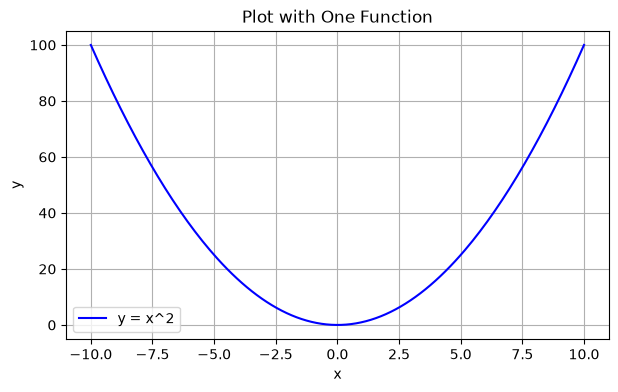

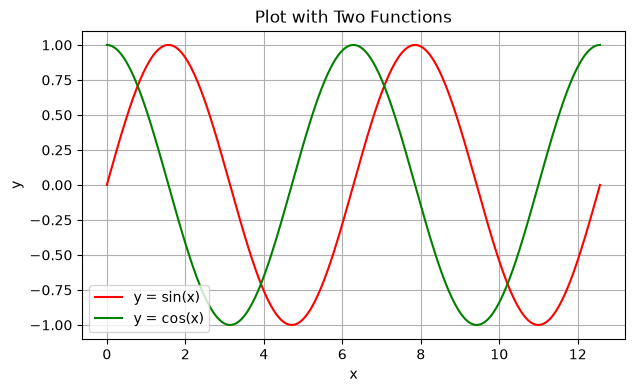

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Plot 1: Single function (y = x^2)
x = np.linspace(-10, 10, 200)
y = x ** 2

plt.figure(figsize=(7, 4))
plt.plot(x, y, color='blue', label='y = x^2')
plt.title('Plot with One Function')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.legend()
plt.show()

# Plot 2: Two functions with two different colors (y = sin(x), y = cos(x))
x_trig = np.linspace(0, 4 * np.pi, 300)
y1 = np.sin(x_trig)
y2 = np.cos(x_trig)

plt.figure(figsize=(7, 4))
plt.plot(x_trig, y1, color='red', label='y = sin(x)')
plt.plot(x_trig, y2, color='green', label='y = cos(x)')
plt.title('Plot with Two Functions')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.legend()
plt.show()

In [7]:
import pandas as pd

# 2. Read chromosome data into a DataFrame
# Use pd.read_excel('chrosome_basepairs.xlsx') if using an .xlsx file
df = pd.read_csv('chrosome_basepairs.csv')  
df.columns = ['Chromosome', 'Base_Pairs']

# 3. Calculate total length assuming 3.4 Å per basepair converted to meters
total_bp = df['Base_Pairs'].sum()

angstrom_per_bp = 3.4
meters_per_angstrom = 1e-10

total_angstroms = total_bp * angstrom_per_bp
total_meters = total_angstroms * meters_per_angstrom

print(f"Total Base Pairs: {total_bp:,} bp")
print(f"Total Length in Angstroms: {total_angstroms:,.1f} Å")
print(f"Total Length in Meters: {total_meters:.4f} m ({total_meters * 100:.2f} cm)")

Total Base Pairs: 3,070,535,648 bp
Total Length in Angstroms: 10,439,821,203.2 Å
Total Length in Meters: 1.0440 m (104.40 cm)


,Year,Cost per Mbps ($),Total Genome Cost ($)
0,2001,10000.00,3.070536e+07
1,2010,1.00,3.070536e+03
2,2011,0.10,3.070536e+02
3,2020,0.01,3.070536e+01


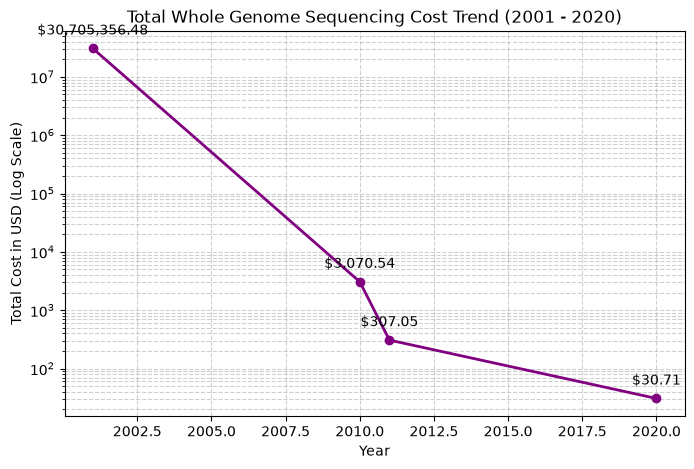

In [8]:
# 4. Calculate sequencing costs (1 Mbps = 1,000,000 base pairs)
years = [2001, 2010, 2011, 2020]
cost_per_mbps = [10000, 1.0, 0.10, 0.01]  # USD per Mbps

total_mbps = total_bp / 1_000_000
total_costs = [rate * total_mbps for rate in cost_per_mbps]

# Display calculated values
cost_df = pd.DataFrame({
    'Year': years,
    'Cost per Mbps ($)': cost_per_mbps,
    'Total Genome Cost ($)': total_costs
})
display(cost_df)

# Plot cost trend (Log scale for clarity across large price ranges)
plt.figure(figsize=(8, 5))
plt.plot(years, total_costs, marker='o', color='purple', linewidth=2)
plt.yscale('log')
plt.title('Total Whole Genome Sequencing Cost Trend (2001 - 2020)')
plt.xlabel('Year')
plt.ylabel('Total Cost in USD (Log Scale)')
plt.grid(True, which='both', linestyle='--', alpha=0.6)

for year, cost in zip(years, total_costs):
    plt.annotate(f"${cost:,.2f}", (year, cost), textcoords="offset points", xytext=(0, 10), ha='center')

plt.show()